In [9]:
print(df.head(9))

NameError: name 'df' is not defined

In [20]:
import pandas as pd

# Datei einlesen
xls_file = pd.ExcelFile("Exp5_Loeslichkeit_Template2025.xls", engine="xlrd")

# Ein bestimmtes Blatt lesen
df = pd.read_excel(xls_file, sheet_name="Tabelle1")

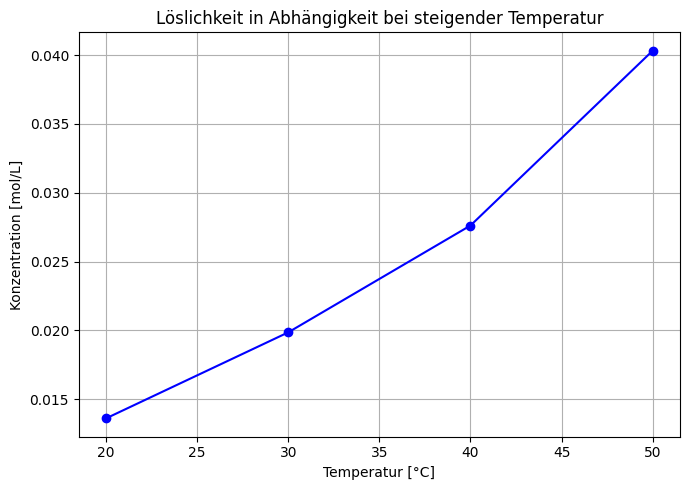

          c   T
0  0.013608  20
1  0.019858  30
2  0.027619  40
3  0.040320  50


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Excel-Datei einlesen
# ===============================
xls_file = pd.ExcelFile("Exp5_Loeslichkeit_Template2025.xls", engine="xlrd")

# Daten aus "Tabelle1", Spalten C und F, ab Zeile 10 (Excel) → skiprows=9
df = pd.read_excel(
    xls_file,
    sheet_name="Tabelle1",
    usecols="F,I",      # Spalte C = Temperatur, F = Konzentration (z. B. Löslichkeit)
    skiprows=7,         # Überspringe 9 Zeilen → starte bei Excel-Zeile 10
    nrows=4            # Anzahl der Datenzeilen (falls bekannt, sonst weglassen)
)

# ===============================
# Spaltennamen setzen
# ===============================
df.columns = ["c","T"]
df = df.dropna()  # Entferne evtl. leere Zeilen

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(df["T"], df["c"], 'o-', color='blue')
plt.xlabel("Temperatur [°C]")
plt.ylabel("Konzentration [mol/L]")
plt.title("Löslichkeit in Abhängigkeit bei steigender Temperatur")
plt.grid(True)
plt.tight_layout()
plt.show()

# ===============================
# Optional: Ausgabe zur Kontrolle
# ===============================
print(df)

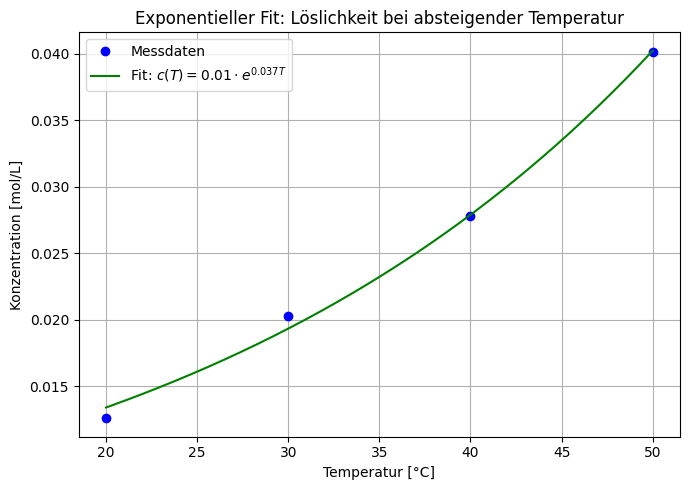

          c   T
0  0.040118  50
1  0.027801  40
2  0.020261  30
3  0.012600  20


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei einlesen
# ===============================
xls_file = pd.ExcelFile("Exp5_Loeslichkeit_Template2025.xls", engine="xlrd")

# Erste Messreihe (z. B. absteigende Temperatur)
df = pd.read_excel(
    xls_file,
    sheet_name="Tabelle1",
    usecols="F,I",
    skiprows=11,
    nrows=4
)

# ===============================
# Spaltennamen setzen
# ===============================
df.columns = ["c", "T"]
df = df.dropna()

# ===============================
# Fit-Funktion (exponentiell)
# ===============================
def exp_func(T, a, b):
    return a * np.exp(b * T)

# Daten für den Fit vorbereiten
T_data = df["T"].values
c_data = df["c"].values

# Fit durchführen
popt, pcov = curve_fit(exp_func, T_data, c_data, p0=[1, 0.01])
a_fit, b_fit = popt

# Fit-Kurve erzeugen
T_fit = np.linspace(min(T_data), max(T_data), 200)
c_fit = exp_func(T_fit, a_fit, b_fit)

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(T_data, c_data, 'o', color='blue', label="Messdaten")
plt.plot(T_fit, c_fit, '-', color='green',
         label=fr'Fit: $c(T) = {a_fit:.2f} \cdot e^{{{b_fit:.3f}T}}$')
plt.xlabel("Temperatur [°C]")
plt.ylabel("Konzentration [mol/L]")
plt.title("Exponentieller Fit: Löslichkeit bei absteigender Temperatur")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ausgabe zur Kontrolle
# ===============================
print(df)

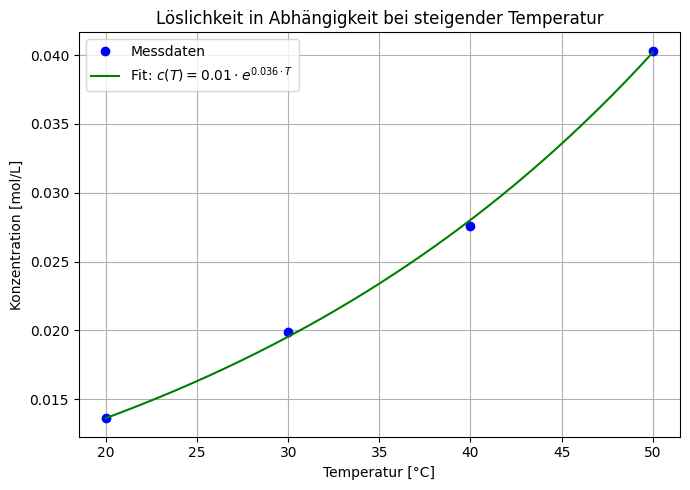

          c   T
0  0.013608  20
1  0.019858  30
2  0.027619  40
3  0.040320  50


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei einlesen
# ===============================
xls_file = pd.ExcelFile("Exp5_Loeslichkeit_Template2025.xls", engine="xlrd")
df = pd.read_excel(
    xls_file,
    sheet_name="Tabelle1",
    usecols="F,I",
    skiprows=7,
    nrows=4
)

# ===============================
# Spaltennamen setzen
# ===============================
df.columns = ["c", "T"]
df = df.dropna()

# ===============================
# Fit-Funktion (exponentiell)
# ===============================
def exp_func(T, a, b):
    return a * np.exp(b * T)

# Fit durchführen
T_data = df["T"].values
c_data = df["c"].values

popt, pcov = curve_fit(exp_func, T_data, c_data, p0=[1, 0.01])
a_fit, b_fit = popt

# Fit-Kurve erzeugen
T_fit = np.linspace(min(T_data), max(T_data), 200)
c_fit = exp_func(T_fit, a_fit, b_fit)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(T_data, c_data, 'o', label="Messdaten", color='blue')
plt.plot(T_fit, c_fit, '-', label=fr'Fit: $c(T) = {a_fit:.2f} \cdot e^{{{b_fit:.3f} \cdot T}}$', color='green')

plt.xlabel("Temperatur [°C]")
plt.ylabel("Konzentration [mol/L]")
plt.title("Löslichkeit in Abhängigkeit bei steigender Temperatur")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ausgabe zur Kontrolle
# ===============================
print(df)

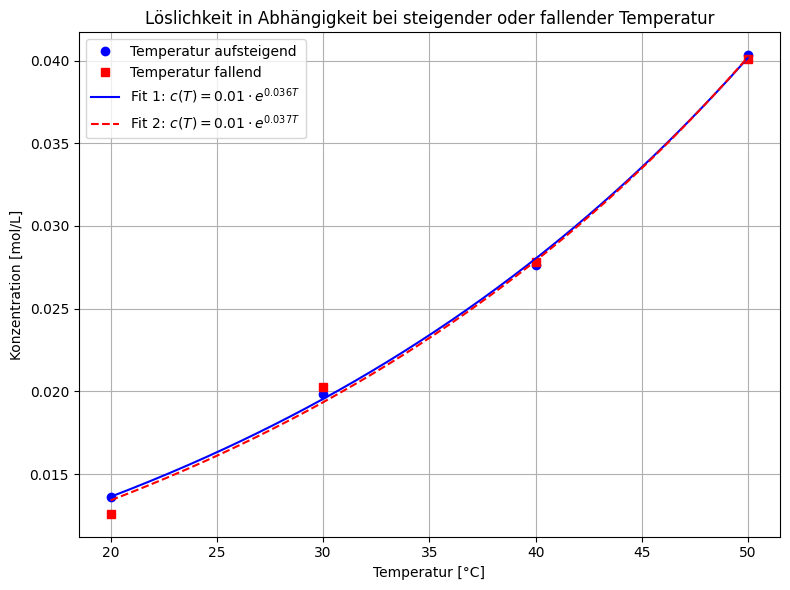

Aufsteigend:
          c   T
0  0.013608  20
1  0.019858  30
2  0.027619  40
3  0.040320  50

Absteigend:
          c   T
0  0.040118  50
1  0.027801  40
2  0.020261  30
3  0.012600  20


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei einlesen
# ===============================
xls_file = pd.ExcelFile("Exp5_Loeslichkeit_Template2025.xls", engine="xlrd")

# Erste Messreihe: aufsteigende Temperatur
df1 = pd.read_excel(xls_file, sheet_name="Tabelle1", usecols="F,I", skiprows=7, nrows=4)
df1.columns = ["c", "T"]
df1 = df1.dropna()

# Zweite Messreihe: absteigende Temperatur
df2 = pd.read_excel(xls_file, sheet_name="Tabelle1", usecols="F,I", skiprows=11, nrows=4)
df2.columns = ["c", "T"]
df2 = df2.dropna()

# ===============================
# Exponentielle Fitfunktion
# ===============================
def exp_func(T, a, b):
    return a * np.exp(b * T)

# Fit für erste Messreihe
T1 = df1["T"].values
c1 = df1["c"].values
popt1, _ = curve_fit(exp_func, T1, c1, p0=[1, 0.01])

# Fit für zweite Messreihe (optional)
T2 = df2["T"].values
c2 = df2["c"].values
popt2, _ = curve_fit(exp_func, T2, c2, p0=[1, 0.01])

# Fit-Kurven
T_fit = np.linspace(min(min(T1), min(T2)), max(max(T1), max(T2)), 200)
c_fit1 = exp_func(T_fit, *popt1)
c_fit2 = exp_func(T_fit, *popt2)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(8, 6))
plt.plot(T1, c1, 'o', label="Temperatur aufsteigend", color='blue')
plt.plot(T2, c2, 's', label="Temperatur fallend", color='red')
plt.plot(T_fit, c_fit1, '-', label=fr'Fit 1: $c(T) = {popt1[0]:.2f} \cdot e^{{{popt1[1]:.3f}T}}$', color='blue')
plt.plot(T_fit, c_fit2, '--', label=fr'Fit 2: $c(T) = {popt2[0]:.2f} \cdot e^{{{popt2[1]:.3f}T}}$', color='red')

plt.xlabel("Temperatur [°C]")
plt.ylabel("Konzentration [mol/L]")
plt.title("Löslichkeit in Abhängigkeit bei steigender oder fallender Temperatur")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ausgabe zur Kontrolle
# ===============================
print("Aufsteigend:")
print(df1)
print("\nAbsteigend:")
print(df2)

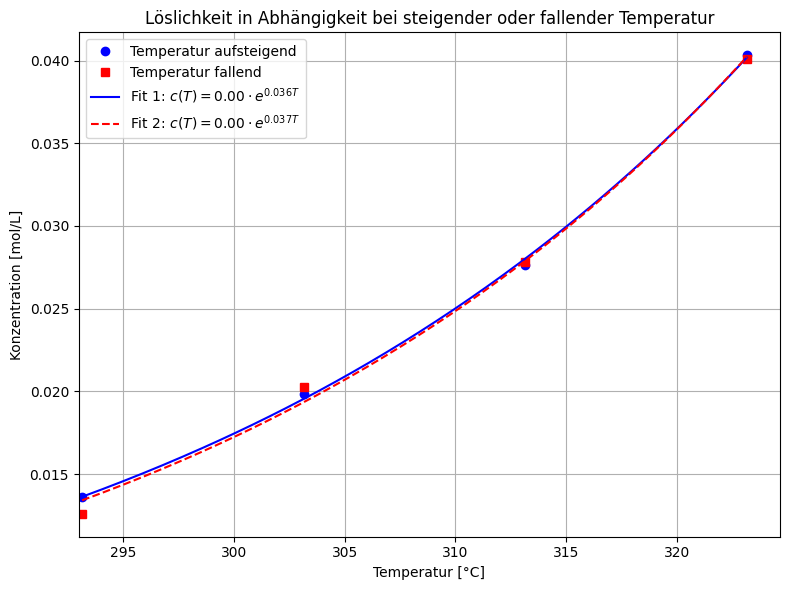

Aufsteigend:
        T         c
0  293.15  0.013608
1  303.15  0.019858
2  313.15  0.027619
3  323.15  0.040320

Absteigend:
        T         c
0  323.15  0.040118
1  313.15  0.027801
2  303.15  0.020261
3  293.15  0.012600


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei einlesen
# ===============================
xls_file = pd.ExcelFile("Exp5_Loeslichkeit_Template2025.xls", engine="xlrd")

# Erste Messreihe: aufsteigende Temperatur
df1 = pd.read_excel(xls_file, sheet_name="Tabelle1", usecols="B,F", skiprows=7, nrows=4)
df1.columns = ["T", "c"]
df1 = df1.dropna()

# Zweite Messreihe: absteigende Temperatur
df2 = pd.read_excel(xls_file, sheet_name="Tabelle1", usecols="B,F", skiprows=11, nrows=4)
df2.columns = ["T", "c"]
df2 = df2.dropna()

# ===============================
# Exponentielle Fitfunktion
# ===============================
def exp_func(T, a, b):
    return a * np.exp(b * T)

# Fit für erste Messreihe
T1 = df1["T"].values
c1 = df1["c"].values
popt1, _ = curve_fit(exp_func, T1, c1, p0=[1, 0.01])

# Fit für zweite Messreihe (optional)
T2 = df2["T"].values
c2 = df2["c"].values
popt2, _ = curve_fit(exp_func, T2, c2, p0=[1, 0.01])

# Fit-Kurven
T_fit = np.linspace(min(min(T1), min(T2)), max(max(T1), max(T2)), 200)
c_fit1 = exp_func(T_fit, *popt1)
c_fit2 = exp_func(T_fit, *popt2)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(8, 6))
plt.plot(T1, c1, 'o', label="Temperatur aufsteigend", color='blue')
plt.plot(T2, c2, 's', label="Temperatur fallend", color='red')
plt.plot(T_fit, c_fit1, '-', label=fr'Fit 1: $c(T) = {popt1[0]:.2f} \cdot e^{{{popt1[1]:.3f}T}}$', color='blue')
plt.plot(T_fit, c_fit2, '--', label=fr'Fit 2: $c(T) = {popt2[0]:.2f} \cdot e^{{{popt2[1]:.3f}T}}$', color='red')

plt.xlabel("Temperatur [°C]")
plt.ylabel("Konzentration [mol/L]")
plt.title("Löslichkeit in Abhängigkeit bei steigender oder fallender Temperatur")
plt.grid(True)
plt.legend()
plt.xlim(293, None)  # x-Achse beginnt bei 293 °C, oberes Limit automatisch
plt.tight_layout()
plt.show()

# ===============================
# Ausgabe zur Kontrolle
# ===============================
print("Aufsteigend:")
print(df1)
print("\nAbsteigend:")
print(df2)